# EchoVision Complete Guide
____________

**This notebook is a start to finish video sound-source localizer tutorial.**

1. First, we need to import some important libraries that are useful for the code

In [15]:
#libraries
import subprocess, os, sys
import cv2
import numpy as np
import requests

import torch
from torch.linalg import norm
import torch.nn.functional as F
from transformers import ClapModel, ClapProcessor
from PIL import Image
import librosa
import clip

import matplotlib.pyplot as plt

2. Next, we are going to load a video, extract the audio and the frames and output some samples!
Use a path to your audio sample or provide a valid url to a video. 
To do that we use the following function

In [5]:
def extract_frames_and_audio(video_path: str, out_dir: str, fps: int = 1):
    """This is the main function to extract audio and frames from a video file."""
    os.makedirs(f"{out_dir}/frames", exist_ok=True)
    # Extract audio
    subprocess.run([
        "ffmpeg", "-i", video_path, "-ac", "1", "-ar", "22050",
        f"{out_dir}/audio.wav", "-y"
    ], check=True)
    # Extract frames at target fps
    cap = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = int(video_fps / fps)
    frames, timestamps = [], []
    idx = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success: break
        if idx % frame_interval == 0:
            frames.append(frame)
            timestamps.append(idx / video_fps)
        idx += 1
    cap.release()
    return frames, timestamps, f"{out_dir}/audio.wav"

Using existing video file: ../sample_video.mp4
Extracted 25 frames and audio saved at output/audio.wav.


Text(0.5, 1.0, 'Sample Extracted Frame')

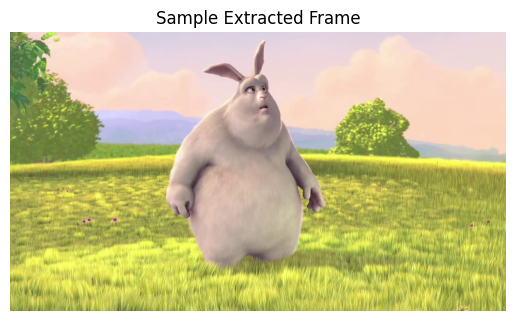

In [17]:
def download_video(url: str, out_path: str):
    print(f"Downloading video from {url}...")

    if os.path.exists(out_path):
        print(f"File {out_path} already exists. Skipping download.")
        return
    
    with requests.get(url, stream=True) as response:
        response.raise_for_status()

        with open(out_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
    print(f"Video saved successfully to {out_path}.")

video_path = "../sample_video.mp4" # Path to your existing input video file
video_url = " " # URL to your input video file (if applicable)
output_dir = "output" # Directory to save extracted frames and audio
if not os.path.exists(output_dir):  
    os.mkdir(output_dir) 

video_file = " "
if video_url != " ":
    # Download the video
    video_file = os.path.join(output_dir, "downloaded_video.mp4")
    download_video(video_url, video_file)
    print(f"Video downloaded to {video_file} successfully! \u2705")
elif video_path != " ":
    video_file = video_path
    print(f"Using existing video file: {video_file}")
else:
    print("No valid video source provided. Please specify a valid video path or URL.")
    exit(1)

# Extract frames and audio
frames, timestamps, audio_path = extract_frames_and_audio(video_file, output_dir)

assert len(frames) > 0, "No frames were extracted."

#Save frames
for i, frame in enumerate(frames):
    cv2.imwrite(f"{output_dir}/frames/frame_{i}.jpg", frame)
    
print(f"Extracted {len(frames)} frames and audio saved at {audio_path}.") 

#Display a sample frame
sample_img = frames[0]
RGB_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB) #Convert BGR to RGB for correct color display
plt.imshow(RGB_img)
plt.axis('off')
plt.title("Sample Extracted Frame")

### **Audio Embedding Extraction**
3. Next we are going to define our audio encoder, which is just a wrapper for the CLAP model, and we are going to extract our audio embeddings from the video audio

In [52]:
class CLAPEncoder:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = ClapModel.from_pretrained(
            "laion/clap-htsat-unfused"
        ).to(self.device).eval()
        self.processor = ClapProcessor.from_pretrained(
            "laion/clap-htsat-unfused"
        )

    @torch.no_grad()
    def encode_segment(self, audio_path: str, start: float, duration: float = 1.0, debug: bool = False):
        audio, sr = librosa.load(audio_path, sr=48000,
                                  offset=start, duration=duration)
        inputs = self.processor(
            audio=audio, sampling_rate=sr, return_tensors="pt"
        ).to(self.device)

        audio_outputs = self.model.audio_model(
        input_features=inputs.input_features,
        is_longer=inputs.is_longer,
        )
        hidden_state = audio_outputs.last_hidden_state
        if debug:
            print(f"Audio hidden state shape: {hidden_state.shape}") 

        pooled = audio_outputs.pooler_output
        if debug:
            print(f"Audio pooled shape: {pooled.shape}")   
        
        # Apply the projection head to get the joint embedding space vector
        audio_emb = self.model.audio_projection(pooled)  # [1, 512]
        if debug:
            print(f"Audio embedding shape: {audio_emb.shape}")

        audio_emb = F.normalize(audio_emb, p=2, dim=-1) # L2 normalize
        return audio_emb.cpu().numpy()

Below is the audio encoder that we are using

In [53]:
encoder = CLAPEncoder()
print(encoder.model.audio_model)

Loading weights: 100%|██████████| 447/447 [00:00<00:00, 50354.63it/s]


ClapAudioModel(
  (audio_encoder): ClapAudioEncoder(
    (patch_embed): ClapAudioPatchEmbed(
      (proj): Conv2d(1, 96, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): ClapAudioStage(
        (blocks): ModuleList(
          (0-1): 2 x ClapAudioLayer(
            (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attention): ClapAudioAttention(
              (self): ClapAudioSelfAttention(
                (query): Linear(in_features=96, out_features=96, bias=True)
                (key): Linear(in_features=96, out_features=96, bias=True)
                (value): Linear(in_features=96, out_features=96, bias=True)
                (dropout): Dropout(p=0.0, inplace=False)
              )
              (output): ClapAudioSelfOutput(
                (dense): Linear(in_features=96, out_features=96, bias=True)
                (dropout): Dropout(p=0.0, inplace=False

In [54]:
#Testing CLAPEncoder embedding extraction
audio_path = f"{output_dir}/audio.wav"
duration = librosa.get_duration(filename=audio_path)
audio_embedding = encoder.encode_segment(audio_path, start=0.0, duration=duration, debug=True) #Encode the entire audio and print debug info

C:\Users\dimko\AppData\Local\Temp\ipykernel_3568\2251259752.py:3: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duration = librosa.get_duration(filename=audio_path)


Audio hidden state shape: torch.Size([1, 768, 2, 32])
Audio pooled shape: torch.Size([1, 768])
Audio embedding shape: torch.Size([1, 512])


### **CLIP Encoder and localization**
4. Now, we are going to define our image encoder and compute a similarity between the audio and each patch of the frames. The logic of the localize function is to project the image embedding into the clap audio embedding space in order to be able to compute a cosine similarity between the two vectors.

In [57]:
class CLIPPatchEncoder:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        # Load ViT-L/14 — gives 16x16=256 patch tokens
        self.model, self.preprocess = clip.load("ViT-L/14", device=self.device)
        self.model.eval()
        self.patch_size = 16  # number of patches per side

    @torch.no_grad()
    def encode_patches(self, frame_bgr: np.ndarray, debug: bool = False):
        """Returns patch embeddings shape"""
        img = Image.fromarray(frame_bgr[:, :, ::-1])  # BGR→RGB
        x = self.preprocess(img).unsqueeze(0).to(self.device)

        patch_tokens = {}
        def hook(module, input, output):
            # output shape: [1, n_patches+1, d] — drop CLS token
            tokens = output[0] if isinstance(output, tuple) else output
            patch_tokens['x'] = tokens[1:, :, :]

        handle = self.model.visual.transformer.resblocks[-1].register_forward_hook(hook)
        self.model.encode_image(x)
        handle.remove()

        feats = patch_tokens['x'].squeeze(1)
        if debug:
            print(f"Raw patch token shape: {feats.shape}")

        # Project 1024 -> 768 
        if self.model.visual.proj is not None:
            feats = feats @ self.model.visual.proj  # [256, 768]
        if debug:
            print(f"Patch token shape after projection: {feats.shape}")

        feats = F.normalize(feats, p=2, dim=-1)  # L2 normalize
        # Reshape to spatial grid
        return feats.view(self.patch_size, self.patch_size, -1)

In [58]:
#Test CLAP encoder
sample_frame = frames[0]
clip_encoder = CLIPPatchEncoder()
features = clip_encoder.encode_patches(sample_frame, debug=True)

Raw patch token shape: torch.Size([256, 1024])
Patch token shape after projection: torch.Size([256, 768])


In [66]:
#Run localization on all frames
proj = torch.nn.Linear(512, 768).to(encoder.device)
def localize(audio_path: str, frame_bgr, timestamp: float):
    audio_emb = encoder.encode_segment(audio_path, start=timestamp, duration=1.0)
    # [1, 512] → [1, 768]
    audio_emb = proj(torch.tensor(audio_emb))
    audio_emb = F.normalize(audio_emb, p=2, dim=-1)

    patch_embs = clip_encoder.encode_patches(frame_bgr)  # [16, 16, 768]

    a = audio_emb.squeeze(0)               # [768]
    p = patch_embs.view(-1, 768)           # [256, 768]
    sim = (p @ a).view(16, 16)             # [16, 16]

    sim = (sim - sim.min()) / (sim.max() - sim.min() + 1e-8)
    return sim.detach().cpu().numpy()

**Run localization on a single frame**

Text(0.5, 1.0, 'Sample Extracted Frame')

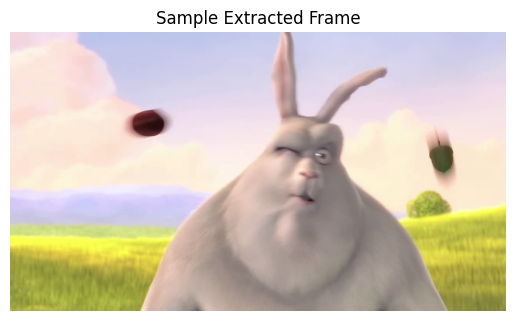

In [71]:
#Display a sample frame
sample_img = frames[18]
RGB_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB) #Convert BGR to RGB for correct color display
plt.imshow(RGB_img)
plt.axis('off')
plt.title("Sample Extracted Frame")

In [72]:
sample_frame = frames[18]
similarity_map = localize(audio_path, sample_frame, timestamps[18])
print("Similarity map shape:", similarity_map.shape)

Similarity map shape: (16, 16)


### **Heatmap Visualization**
5. Having a similarity patch between the frame and the audio at that moment, we can create a heatmap

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

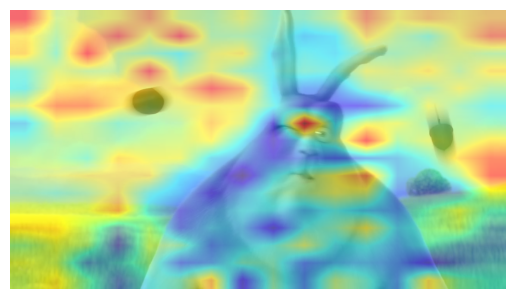

In [74]:
def overlay_heatmap(frame_bgr, sim_map, alpha=0.5):
    height, width = frame_bgr.shape[:2]
    # Upsample similarity map to frame size
    heatmap = cv2.resize(sim_map.astype(np.float32), (width, height),
                          interpolation=cv2.INTER_LINEAR)
    heatmap_uint8 = (heatmap * 255).astype(np.uint8)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    return cv2.addWeighted(frame_bgr, 1 - alpha, heatmap_color, alpha, 0)

#Visualize the similarity map overlayed on the frame
overlayed = overlay_heatmap(sample_frame, similarity_map)
RGB_overlayed = cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_overlayed)
plt.axis('off')

**You are ready to run the full localization to all frames of the video. Simply run python run_simply.py or launch a gradio app by running python app.py**